# Chapter 11 — Uniform Random Text Generation

Chapter 10 turned token-ID sequences into next-token examples.

This chapter builds the simplest model that can assign probabilities and generate new tokens.

By the end of the chapter, you will be able to:

- define a baseline model and a uniform probability distribution;
- construct and validate uniform next-token probabilities;
- sample and decode character IDs deterministically;
- generate one character at a time through a reusable model interface;
- prove that this model ignores its context; and
- state the uniform model's exact per-token loss.

The model uses the corpus vocabulary but does not learn from token order or frequency.

## Why Begin with an Intentionally Weak Baseline

A **baseline** is a simple reference against which later models can be compared.

It should be understandable and reproducible before it is sophisticated.

The uniform model answers a narrow question: what happens when every vocabulary token is equally likely at every step?

Later models should improve on both its generated text and its numerical loss.

## Define the Uniform Distribution

A **probability distribution** assigns a probability to every possible outcome.

Every probability must be finite and nonnegative, and the probabilities must sum to 1.

A **uniform distribution** over `V` vocabulary tokens assigns probability `1 / V` to each token.

The distribution is valid, but validity alone does not make it a good model of text.

## Reuse the Prepared Character Fixture

The fixture supplies the set of characters the model may generate.

The model will not inspect their order or count how often they appear when constructing its probabilities.

In [1]:
prepared_text = (
    "The dog ran across the yard.\n"
    "The cat sat near the window.\n"
    "\n"
    "The dog looked at the cat!\n"
    "The cat looked back."
)

print(prepared_text)
print()
print("Representation:", repr(prepared_text))

The dog ran across the yard.
The cat sat near the window.

The dog looked at the cat!
The cat looked back.

Representation: 'The dog ran across the yard.\nThe cat sat near the window.\n\nThe dog looked at the cat!\nThe cat looked back.'


## Build the Vocabulary and ID Mappings

Sorting the unique characters gives the notebook a deterministic mapping.

The IDs remain arbitrary labels rather than measurements of character meaning.

In [2]:
def build_character_mappings(
    text: str,
) -> tuple[list[str], dict[str, int], dict[int, str]]:
    vocabulary = sorted(set(text))
    character_to_id = {
        character: character_id for character_id, character in enumerate(vocabulary)
    }
    id_to_character = {
        character_id: character for character, character_id in character_to_id.items()
    }
    return vocabulary, character_to_id, id_to_character


character_vocabulary, character_to_id, id_to_character = build_character_mappings(
    prepared_text
)

for character_id, character in enumerate(character_vocabulary):
    print(f"{character_id:>2}: {character!r}")

print("Vocabulary size:", len(character_vocabulary))

 0: '\n'
 1: ' '
 2: '!'
 3: '.'
 4: 'T'
 5: 'a'
 6: 'b'
 7: 'c'
 8: 'd'
 9: 'e'
10: 'g'
11: 'h'
12: 'i'
13: 'k'
14: 'l'
15: 'n'
16: 'o'
17: 'r'
18: 's'
19: 't'
20: 'w'
21: 'y'
Vocabulary size: 22


## Keep Encoding and Decoding Explicit

The encoder rejects characters outside the vocabulary.

The decoder rejects IDs that have no corresponding character.

In [3]:
def encode_characters(
    text: str,
    character_to_id: dict[str, int],
) -> list[int]:
    character_ids = []

    for position, character in enumerate(text):
        if character not in character_to_id:
            raise ValueError(
                f"Cannot encode character {character!r} at position {position}."
            )
        character_ids.append(character_to_id[character])

    return character_ids


def decode_character_ids(
    character_ids: list[int],
    id_to_character: dict[int, str],
) -> str:
    characters = []

    for position, character_id in enumerate(character_ids):
        if character_id not in id_to_character:
            raise ValueError(
                f"Cannot decode character ID {character_id} at position {position}."
            )
        characters.append(id_to_character[character_id])

    return "".join(characters)

In [4]:
prepared_character_ids = encode_characters(prepared_text, character_to_id)
decoded_prepared_text = decode_character_ids(
    prepared_character_ids,
    id_to_character,
)

assert decoded_prepared_text == prepared_text

print("First 60 IDs:", prepared_character_ids[:60])
print("Exact round trip:", decoded_prepared_text == prepared_text)

First 60 IDs: [4, 11, 9, 1, 8, 16, 10, 1, 17, 5, 15, 1, 5, 7, 17, 16, 18, 18, 1, 19, 11, 9, 1, 21, 5, 17, 8, 3, 0, 4, 11, 9, 1, 7, 5, 19, 1, 18, 5, 19, 1, 15, 9, 5, 17, 1, 19, 11, 9, 1, 20, 12, 15, 8, 16, 20, 3, 0, 0, 4]
Exact round trip: True


## Construct Uniform Probabilities

The model needs one probability for each vocabulary ID in the same order as the ID mapping.

An empty vocabulary cannot define this distribution because division by zero would be required.

In [5]:
def build_uniform_probabilities(vocabulary_size: int) -> list[float]:
    if vocabulary_size < 1:
        raise ValueError("vocabulary_size must be at least 1.")

    probability = 1.0 / vocabulary_size
    return [probability for _ in range(vocabulary_size)]


vocabulary_size = len(character_vocabulary)
uniform_probabilities = build_uniform_probabilities(vocabulary_size)

print("Vocabulary size:", vocabulary_size)
print("Probability per token:", uniform_probabilities[0])
print("Probability count:", len(uniform_probabilities))

Vocabulary size: 22
Probability per token: 0.045454545454545456
Probability count: 22


## Validate Probability Distributions

The validator checks length, finiteness, nonnegativity, and total probability.

Floating-point sums are compared with a small tolerance rather than exact equality.

In [6]:
import math


def validate_probability_distribution(probabilities: list[float]) -> None:
    if not probabilities:
        raise ValueError("A probability distribution cannot be empty.")

    for probability in probabilities:
        if not math.isfinite(probability):
            raise ValueError("Every probability must be finite.")
        if probability < 0:
            raise ValueError("Probabilities cannot be negative.")

    if not math.isclose(sum(probabilities), 1.0, abs_tol=1e-12):
        raise ValueError("Probabilities must sum to 1.")


validate_probability_distribution(uniform_probabilities)

print("Probability sum:", sum(uniform_probabilities))
print("Distribution is valid.")

Probability sum: 1.0
Distribution is valid.


Every character receives the same value, including spaces, newlines, punctuation, and letters.

Using `repr` keeps invisible characters readable in the table.

In [7]:
print("ID | Character | Probability")
print("-" * 30)
for character_id, character in enumerate(character_vocabulary):
    print(
        f"{character_id:>2} | "
        f"{character!r:>9} | "
        f"{uniform_probabilities[character_id]:.6f}"
    )

ID | Character | Probability
------------------------------
 0 |      '\n' | 0.045455
 1 |       ' ' | 0.045455
 2 |       '!' | 0.045455
 3 |       '.' | 0.045455
 4 |       'T' | 0.045455
 5 |       'a' | 0.045455
 6 |       'b' | 0.045455
 7 |       'c' | 0.045455
 8 |       'd' | 0.045455
 9 |       'e' | 0.045455
10 |       'g' | 0.045455
11 |       'h' | 0.045455
12 |       'i' | 0.045455
13 |       'k' | 0.045455
14 |       'l' | 0.045455
15 |       'n' | 0.045455
16 |       'o' | 0.045455
17 |       'r' | 0.045455
18 |       's' | 0.045455
19 |       't' | 0.045455
20 |       'w' | 0.045455
21 |       'y' | 0.045455


## Give the Baseline a Numerical Loss

Chapter 2 introduced negative log loss for the correct target.

The uniform model gives every possible target probability `1 / V`, so every target has the same loss `-log(1 / V) = log(V)`.

This value is independent of the context and the identity of the correct token.

In [8]:
uniform_target_probability = 1.0 / vocabulary_size
uniform_loss_per_token = -math.log(uniform_target_probability)

print("Uniform target probability:", uniform_target_probability)
print("Uniform loss per token:", uniform_loss_per_token)
print("log(vocabulary size):", math.log(vocabulary_size))

assert math.isclose(uniform_loss_per_token, math.log(vocabulary_size))

Uniform target probability: 0.045454545454545456
Uniform loss per token: 3.0910424533583156
log(vocabulary size): 3.091042453358316


Any later model evaluated on the same vocabulary and targets should achieve an average loss below this baseline to demonstrate useful predictive information.

Comparing losses across different tokenizers or vocabularies requires more care because the prediction tasks differ.

## Sample One Token ID

**Sampling** chooses an outcome according to its probability.

A local seeded random generator makes the stored demonstration reproducible without changing global random state.

In [9]:
import random  # noqa: I001


RANDOM_SEED = 11


def sample_token_id(
    probabilities: list[float],
    random_generator: random.Random,
) -> int:
    validate_probability_distribution(probabilities)
    possible_token_ids = list(range(len(probabilities)))
    return random_generator.choices(
        possible_token_ids,
        weights=probabilities,
        k=1,
    )[0]


random_generator = random.Random(RANDOM_SEED)
sampled_token_id = sample_token_id(uniform_probabilities, random_generator)

print("Sampled ID:", sampled_token_id)
print("Sampled character:", repr(id_to_character[sampled_token_id]))

Sampled ID: 9
Sampled character: 'e'


## Sample a Reproducible Character Sequence

Repeated independent draws create a sequence of valid vocabulary IDs.

The model does not use preceding draws to change the next distribution.

In [10]:
random_generator = random.Random(RANDOM_SEED)
sampled_token_ids = [
    sample_token_id(uniform_probabilities, random_generator) for _ in range(60)
]
sampled_text = decode_character_ids(sampled_token_ids, id_to_character)

print(sampled_text)
print()
print("Representation:", repr(sampled_text))

eiwghiThkr!b rn
yylk.
h Ta
geshlglgbyysnbab odsdys
Twgyd kra

Representation: 'eiwghiThkr!b rn\nyylk.\nh Ta\ngeshlglgbyysnbab odsdys\nTwgyd kra'


The output contains valid characters but little recognizable structure.

The model does not know that spaces are common, punctuation usually follows words, or particular letters tend to follow one another.

## Wrap the Distribution in a Model Interface

A next-token model maps input token IDs to probabilities for the next token.

The uniform model accepts that input for interface compatibility but deliberately ignores its values.

In [11]:
class UniformCharacterModel:
    def __init__(self, vocabulary_size: int):
        self.vocabulary_size = vocabulary_size
        self._probabilities = build_uniform_probabilities(vocabulary_size)

    def predict_next_token_probabilities(
        self,
        input_token_ids: list[int],
    ) -> list[float]:
        del input_token_ids
        return self._probabilities.copy()


uniform_model = UniformCharacterModel(vocabulary_size)

context_a = encode_characters("The ", character_to_id)
context_b = encode_characters("cat", character_to_id)

probabilities_a = uniform_model.predict_next_token_probabilities(context_a)
probabilities_b = uniform_model.predict_next_token_probabilities(context_b)

print("Same distribution:", probabilities_a == probabilities_b)
assert probabilities_a == probabilities_b

Same distribution: True


Returning a copy prevents external code from accidentally changing the model's stored distribution.

The equality check proves that these two contexts have no effect on its prediction.

## Generate One Character at a Time

The generation loop encodes the current text, requests next-token probabilities, samples one ID, decodes it, and appends the character.

This structure can be reused when later models begin using context.

In [12]:
def generate_text(
    model: UniformCharacterModel,
    prompt: str,
    number_of_new_characters: int,
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
    random_seed: int,
) -> str:
    if number_of_new_characters < 0:
        raise ValueError("number_of_new_characters cannot be negative.")

    random_generator = random.Random(random_seed)
    generated_text = prompt

    for _ in range(number_of_new_characters):
        input_token_ids = encode_characters(generated_text, character_to_id)
        probabilities = model.predict_next_token_probabilities(input_token_ids)
        next_token_id = sample_token_id(probabilities, random_generator)
        generated_text += id_to_character[next_token_id]

    return generated_text

In [13]:
generated_text = generate_text(
    model=uniform_model,
    prompt="The ",
    number_of_new_characters=120,
    character_to_id=character_to_id,
    id_to_character=id_to_character,
    random_seed=RANDOM_SEED,
)

print(generated_text)
print()
print("Representation:", repr(generated_text))

The eiwghiThkr!b rn
yylk.
h Ta
geshlglgbyysnbab odsdys
Twgyd kra cyo!a! r.ieTo!l!eTayrbtTdsl!yTaocb  iakdeygitT.traTowTwtke!

Representation: 'The eiwghiThkr!b rn\nyylk.\nh Ta\ngeshlglgbyysnbab odsdys\nTwgyd kra cyo!a! r.ieTo!l!eTayrbtTdsl!yTaocb  iakdeygitT.traTowTwtke!'


The prompt appears only because generation starts with it.

The generated suffix is not a context-aware continuation.

## Prove That the Prompt Is Ignored

Using the same seed with different valid prompts produces identical sampled suffixes.

Only the manually supplied prefixes differ.

In [14]:
cat_generation = generate_text(
    uniform_model,
    "The cat ",
    60,
    character_to_id,
    id_to_character,
    RANDOM_SEED,
)
dog_generation = generate_text(
    uniform_model,
    "The dog ",
    60,
    character_to_id,
    id_to_character,
    RANDOM_SEED,
)

cat_suffix = cat_generation[len("The cat ") :]
dog_suffix = dog_generation[len("The dog ") :]

print("Cat prompt result:", repr(cat_generation))
print("Dog prompt result:", repr(dog_generation))
print("Suffixes match:", cat_suffix == dog_suffix)

assert cat_suffix == dog_suffix

Cat prompt result: 'The cat eiwghiThkr!b rn\nyylk.\nh Ta\ngeshlglgbyysnbab odsdys\nTwgyd kra'
Dog prompt result: 'The dog eiwghiThkr!b rn\nyylk.\nh Ta\ngeshlglgbyysnbab odsdys\nTwgyd kra'
Suffixes match: True


## Verify the Vocabulary Boundary

Sampling IDs from `0` through `V - 1` guarantees that every generated character belongs to the known vocabulary.

It also means the model cannot directly produce any character outside that vocabulary.

In [15]:
generated_suffix = generated_text[len("The ") :]
outside_vocabulary = set(generated_suffix) - set(character_vocabulary)

print("Generated characters:")
print([repr(character) for character in sorted(set(generated_suffix))])
print("Outside vocabulary:", outside_vocabulary)

assert not outside_vocabulary

Generated characters:
["'\\n'", "' '", "'!'", "'.'", "'T'", "'a'", "'b'", "'c'", "'d'", "'e'", "'g'", "'h'", "'i'", "'k'", "'l'", "'n'", "'o'", "'r'", "'s'", "'t'", "'w'", "'y'"]
Outside vocabulary: set()


## Compare Uniform Probabilities with Corpus Frequencies

The uniform model uses the corpus only to discover which characters exist.

Actual corpus counts reveal that those characters do not occur equally often.

In [16]:
training_counts = {
    character: prepared_text.count(character) for character in character_vocabulary
}
training_frequencies = [
    training_counts[character] / len(prepared_text)
    for character in character_vocabulary
]

print("Character | Corpus frequency | Uniform probability")
print("-" * 51)
for character, frequency, probability in zip(
    character_vocabulary,
    training_frequencies,
    uniform_probabilities,
    strict=True,
):
    print(f"{character!r:>9} | {frequency:>16.6f} | {probability:>19.6f}")

Character | Corpus frequency | Uniform probability
---------------------------------------------------
     '\n' |         0.037736 |            0.045455
      ' ' |         0.169811 |            0.045455
      '!' |         0.009434 |            0.045455
      '.' |         0.028302 |            0.045455
      'T' |         0.037736 |            0.045455
      'a' |         0.094340 |            0.045455
      'b' |         0.009434 |            0.045455
      'c' |         0.047170 |            0.045455
      'd' |         0.056604 |            0.045455
      'e' |         0.094340 |            0.045455
      'g' |         0.018868 |            0.045455
      'h' |         0.066038 |            0.045455
      'i' |         0.009434 |            0.045455
      'k' |         0.028302 |            0.045455
      'l' |         0.018868 |            0.045455
      'n' |         0.028302 |            0.045455
      'o' |         0.075472 |            0.045455
      'r' |         0.037736 |

The comparison plot has one purpose: show that a flat model distribution does not match the uneven character frequencies in the fixture.

Those empirical frequencies will motivate the next chapter's unigram model.

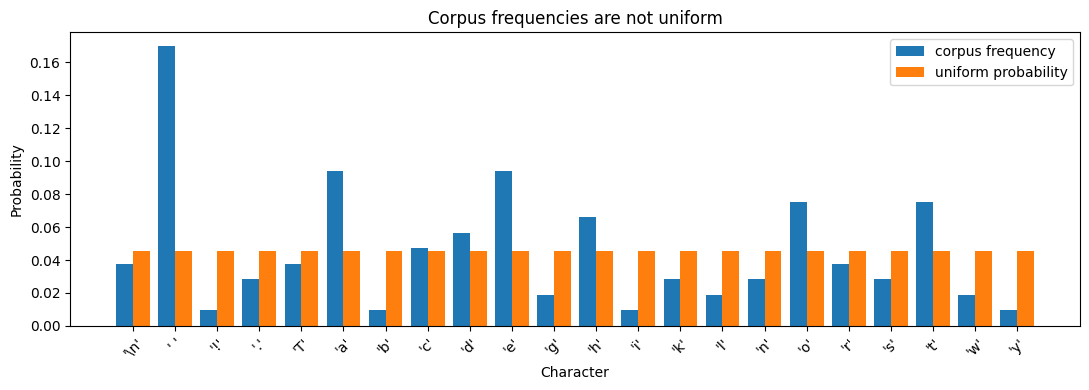

In [17]:
import matplotlib.pyplot as plt  # noqa: I001


x_positions = list(range(vocabulary_size))
bar_width = 0.4

plt.figure(figsize=(11, 4))
plt.bar(
    [position - bar_width / 2 for position in x_positions],
    training_frequencies,
    width=bar_width,
    label="corpus frequency",
)
plt.bar(
    [position + bar_width / 2 for position in x_positions],
    uniform_probabilities,
    width=bar_width,
    label="uniform probability",
)
plt.xlabel("Character")
plt.ylabel("Probability")
plt.title("Corpus frequencies are not uniform")
plt.xticks(
    x_positions,
    [repr(character) for character in character_vocabulary],
    rotation=45,
)
plt.legend()
plt.tight_layout()
plt.show()

## Check Long-Run Sampling Behavior

Uniform draws should produce approximately equal counts over many samples.

Random variation prevents exact equality in a finite sample.

In [18]:
random_generator = random.Random(RANDOM_SEED)
sample_size = 10_000
sampled_ids = [
    sample_token_id(uniform_probabilities, random_generator) for _ in range(sample_size)
]
sampled_counts = dict.fromkeys(character_vocabulary, 0)

for token_id in sampled_ids:
    sampled_counts[id_to_character[token_id]] += 1

expected_count = sample_size / vocabulary_size
print("Expected count per character:", expected_count)
print("Minimum sampled count:", min(sampled_counts.values()))
print("Maximum sampled count:", max(sampled_counts.values()))

Expected count per character: 454.54545454545456
Minimum sampled count: 425
Maximum sampled count: 495


The sampled counts cluster around the same expectation, unlike the uneven corpus counts.

This confirms that the generator behaves as its uniform probabilities specify.

## What the Baseline Knows

The uniform model knows:

- the vocabulary size;
- which token IDs are valid; and
- that every token receives equal probability.

It does not know:

- token frequencies;
- token order;
- spelling or punctuation patterns;
- which characters follow a prompt; or
- any relationship between context and the next token.

## Takeaways

- A baseline is a simple reference for measuring later improvement.
- A uniform model assigns probability `1 / V` to each of `V` vocabulary tokens.
- Its probability distribution is valid even though it is a poor model of language.
- Its per-token negative log loss is exactly `log(V)`.
- Seeded sampling makes random notebook output reproducible.
- The generation loop produces one vocabulary token at a time.
- Identical suffixes after different prompts prove that the model ignores context.
- Corpus character frequencies are uneven, while uniform probabilities are flat.

The next chapter will build a unigram model that still ignores context but learns those marginal character frequencies from data.